# Sweep Results
Loads all `best.pt` checkpoints and visualizes val loss and 2AFC across hyperparameters.

In [1]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR

# ── collect encoder best.pt checkpoints ──────────────────────────────────────
ENCODER_MODELS  = ["mlp", "lstm", "transformer"]
ENCODER_TARGETS = ["siglip", "clip"]

candidates = []
for model_name in ENCODER_MODELS:
    for tgt in ENCODER_TARGETS:
        pattern_dir = CHECKPOINT_DIR / model_name / tgt
        if not pattern_dir.exists():
            pattern_dir = CHECKPOINT_DIR / model_name
        candidates.extend((tgt, pt) for pt in sorted(pattern_dir.glob("*/best.pt")))

def load_one(tgt_pt):
    tgt, pt = tgt_pt
    try:
        ckpt = torch.load(pt, weights_only=False, map_location="cpu")
    except Exception as e:
        return None, (pt, str(e))
    if "metrics" not in ckpt:
        return None, None
    args = ckpt["args"]
    if "target" not in args:
        args["target"] = tgt
    return {**args, **ckpt["metrics"], "path": str(pt)}, None

records, skipped = [], []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, c): c for c in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Loading checkpoints"):
        row, err = fut.result()
        if err:
            skipped.append(err)
        elif row:
            records.append(row)

if skipped:
    print(f"Skipped {len(skipped)} unreadable checkpoints:")
    for pt, err in skipped:
        print(f"  {pt.name}: {err}")

df = pd.DataFrame(records)
print(f"{len(df)} runs loaded")
df.head()

Loading checkpoints:   0%|          | 0/122 [00:00<?, ?it/s]

Skipped 1 unreadable checkpoints:
  best.pt: PytorchStreamReader failed reading file data/0: file read failed
121 runs loaded


,model,target,bottleneck,hidden,d_model,n_heads,n_layers,dropout,target_noise,epochs,batch_size,lr,weight_decay,temperature,epoch,train_loss,val_loss,val_2afc,path
0,mlp,siglip,128,128,128,4,1,0.1,0.0,150,64,0.0010,0.10,0.07,107,0.232819,3.126829,0.845306,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...
1,mlp,siglip,128,128,128,4,1,0.1,0.0,150,64,0.0010,0.01,0.07,107,0.233344,3.129164,0.842041,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...
2,mlp,siglip,128,128,128,4,1,0.1,0.0,150,64,0.0003,0.01,0.07,107,0.419132,3.162371,0.828571,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...
3,mlp,siglip,128,128,128,4,1,0.3,0.0,150,64,0.0003,0.01,0.07,121,0.609080,3.176666,0.827347,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...
4,mlp,siglip,64,128,128,4,1,0.1,0.0,150,64,0.0003,0.10,0.07,134,0.828842,3.273790,0.798367,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...


In [2]:
# Friendly label for each run
def make_arch(row):
    m = row["model"]
    if m == "mlp":
        return f"bn{int(row['bottleneck'])}"
    elif m == "lstm":
        return f"h{int(row['hidden'])}"
    else:
        return f"d{int(row['d_model'])}_nl{int(row['n_layers'])}"

df["arch"]   = df.apply(make_arch, axis=1)
df["label"]  = df.apply(
    lambda r: f"[{r['target']}] {r['model']} {make_arch(r)} do={r['dropout']} lr={r['lr']:.0e} wd={r['weight_decay']:.0e}",
    axis=1,
)

TARGETS  = sorted(df["target"].unique())
MODELS   = sorted(df["model"].unique())
TARGET_PALETTE = {"siglip": "tab:blue", "clip": "tab:orange"}
MODEL_PALETTE  = dict(zip(MODELS, ["tab:blue", "tab:orange", "tab:green"]))

## Best run per model × target

In [3]:
cols = ["target", "model", "arch", "dropout", "lr", "weight_decay", "epoch", "train_loss", "val_loss", "val_2afc"]
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values("val_2afc", ascending=False)
      .groupby(["target", "model"], sort=False)
      .first()
      .reset_index()
)[available]
summary

,target,model,arch,dropout,lr,weight_decay,epoch,train_loss,val_loss,val_2afc
0,clip,mlp,bn128,0.3,0.0010,0.10,122,0.333931,3.100570,0.848980
1,siglip,mlp,bn128,0.1,0.0010,0.10,107,0.232819,3.126829,0.845306
2,siglip,transformer,d128_nl1,0.3,0.0003,0.01,112,1.045069,3.173098,0.821224
3,siglip,lstm,h128,0.3,0.0010,0.01,22,1.665712,3.498878,0.755918
4,clip,transformer,d128_nl2,0.3,0.0003,0.01,77,2.209320,7.467990,0.601224
5,clip,lstm,h256,0.1,0.0003,0.01,5,3.688537,11.377689,0.554286


## Val loss vs 2AFC — faceted by target, coloured by model

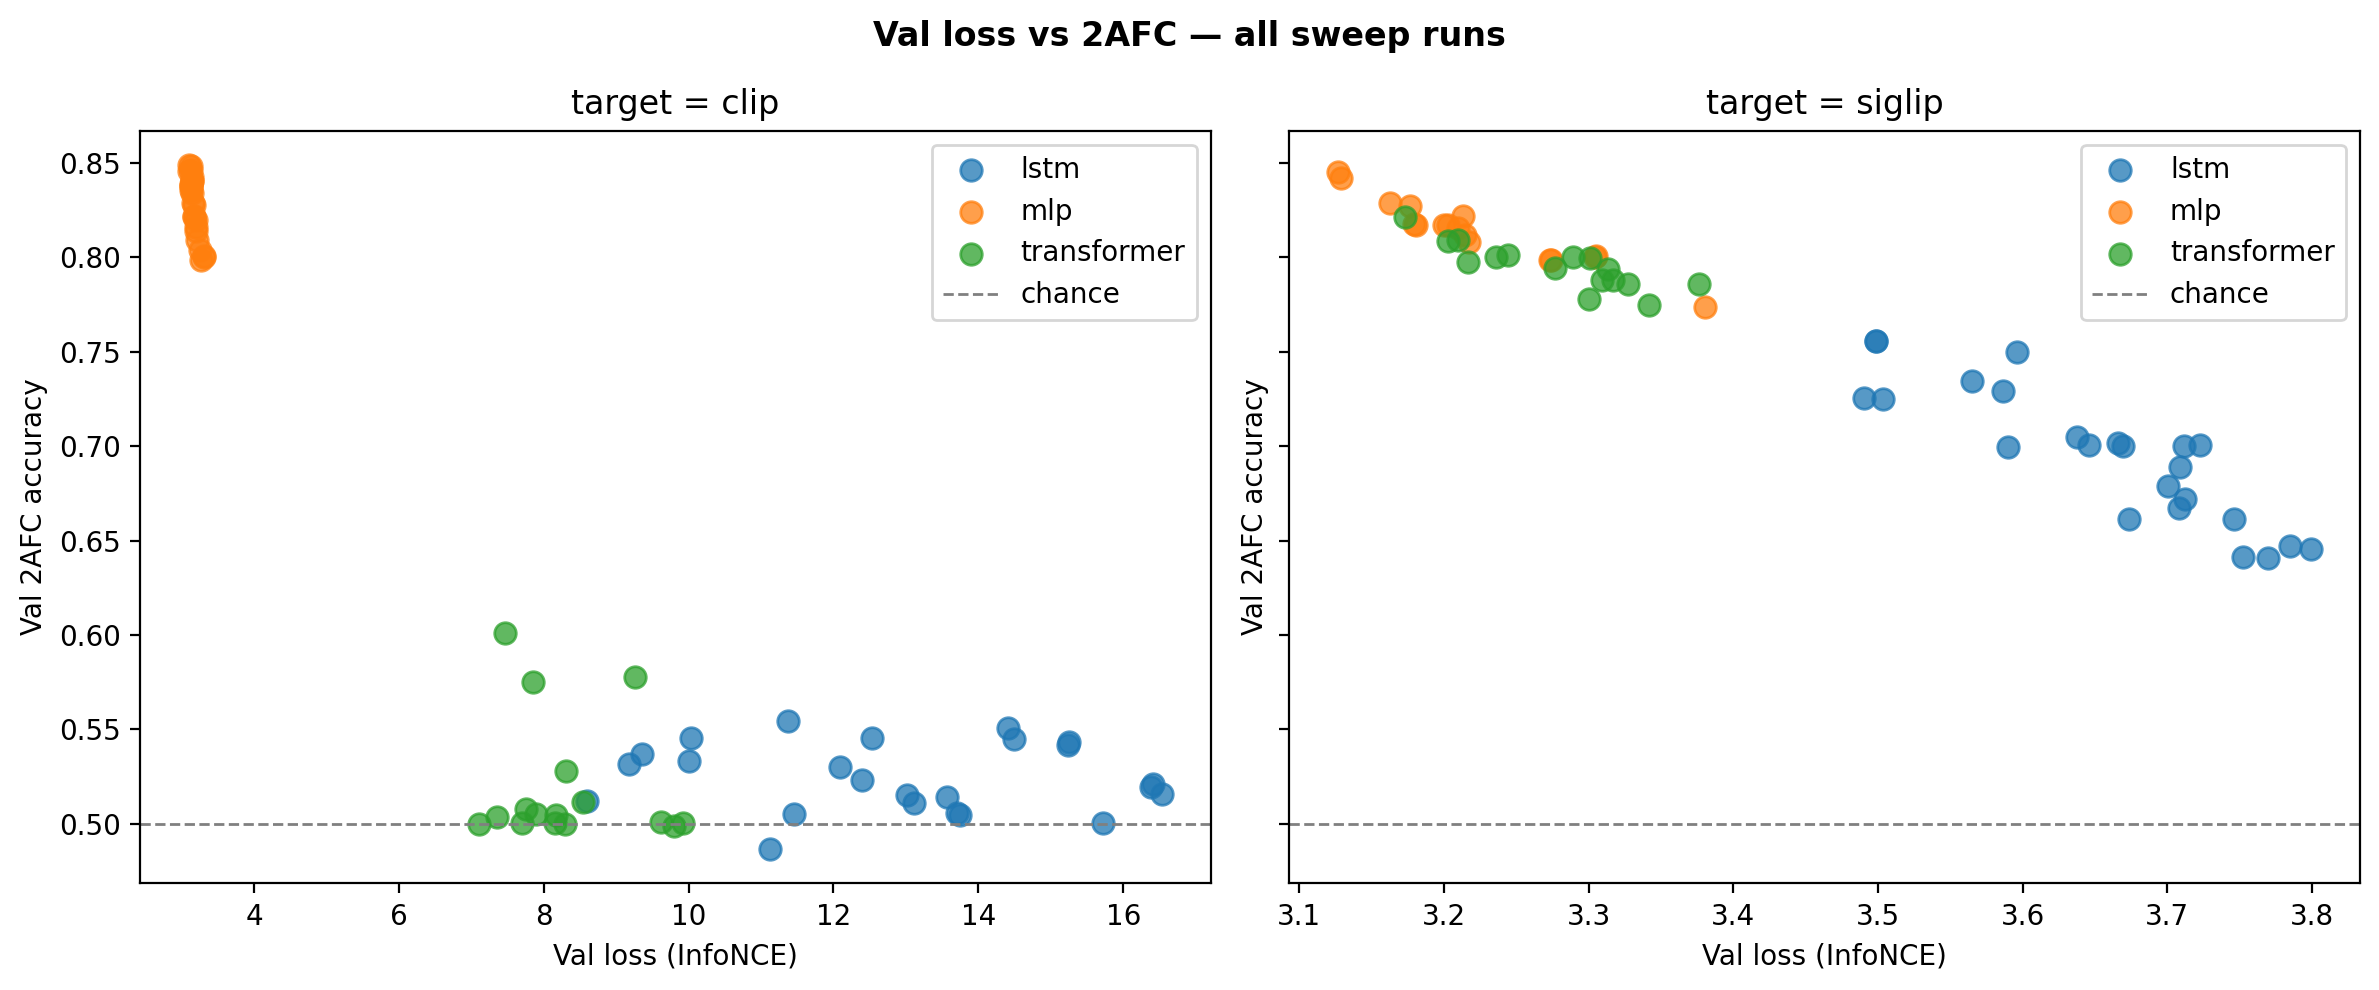

In [4]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(6 * len(TARGETS), 5), sharey=True)
if len(TARGETS) == 1:
    axes = [axes]

for ax, tgt in zip(axes, TARGETS):
    sub = df[df["target"] == tgt]
    for model, grp in sub.groupby("model"):
        ax.scatter(grp["val_loss"], grp["val_2afc"],
                   label=model, color=MODEL_PALETTE[model], alpha=0.75, s=60)
    ax.axhline(0.5, color="grey", lw=1, ls="--", label="chance")
    ax.set_xlabel("Val loss (InfoNCE)")
    ax.set_ylabel("Val 2AFC accuracy")
    ax.set_title(f"target = {tgt}")
    ax.legend()

fig.suptitle("Val loss vs 2AFC — all sweep runs", fontweight="bold")
plt.tight_layout()
plt.show()

## 2AFC by hyperparameter — per model × target

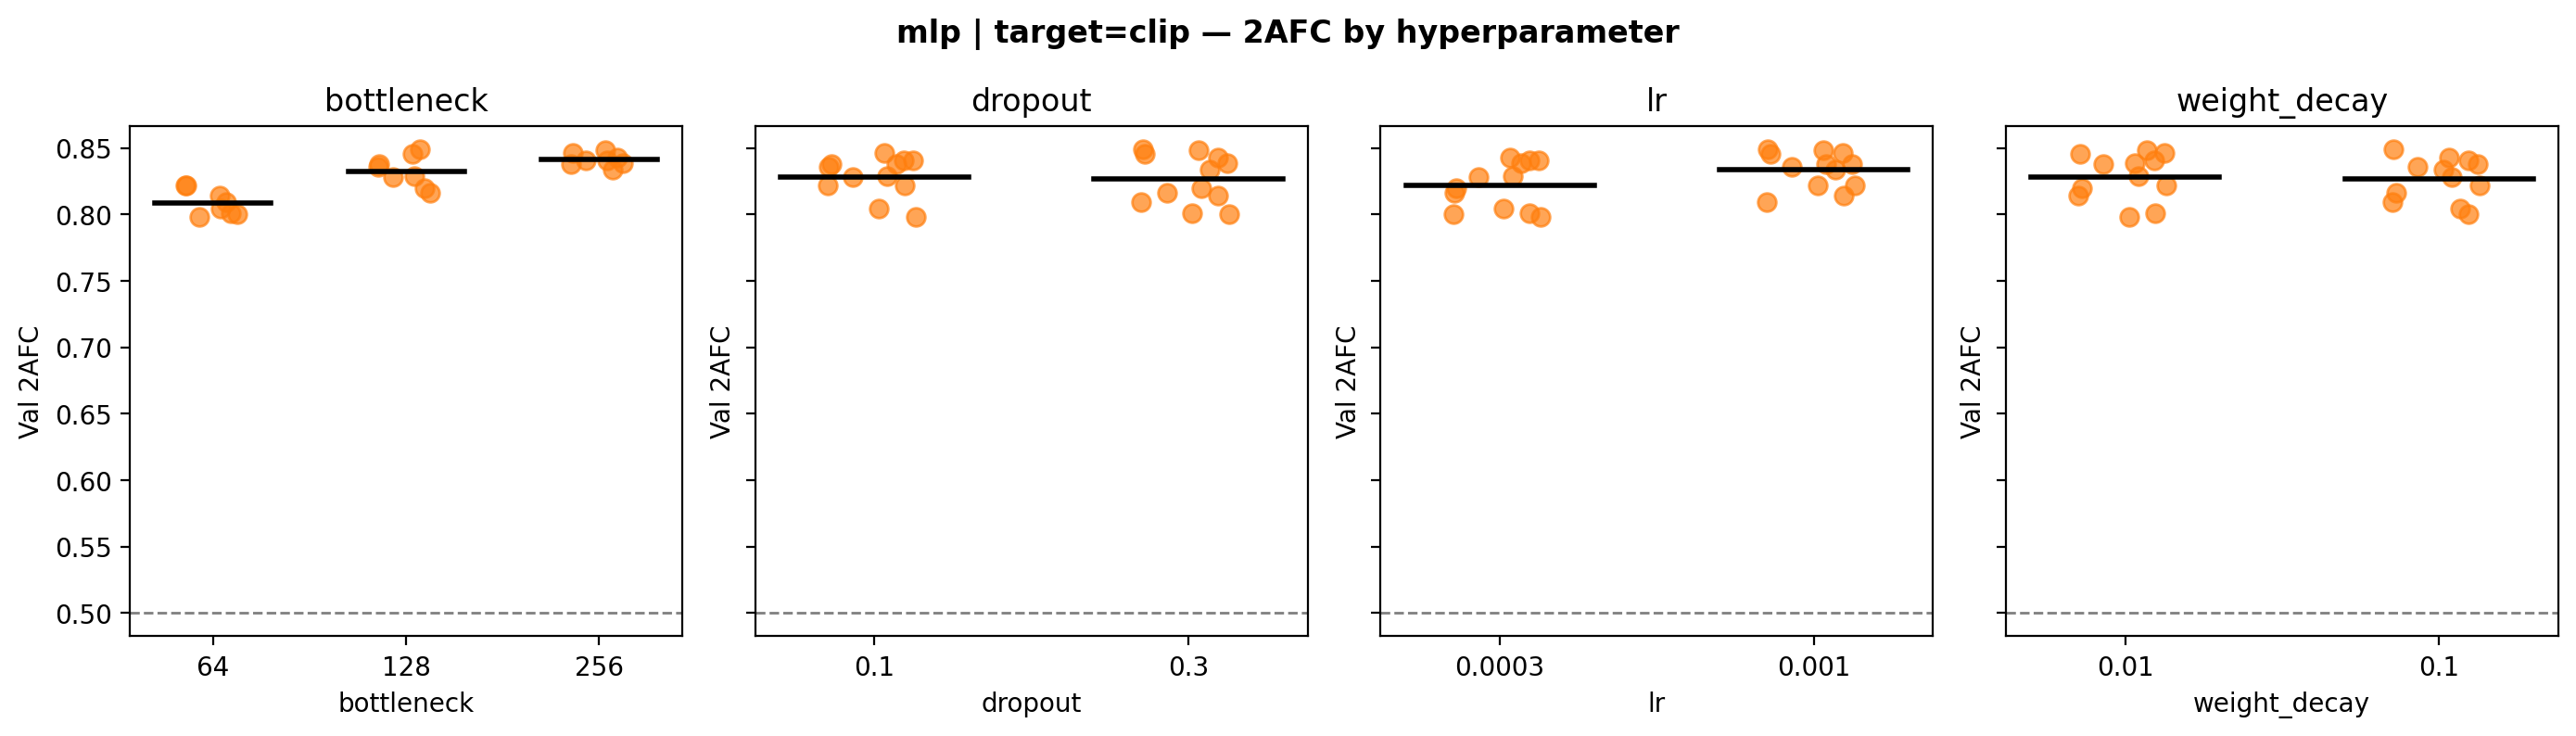

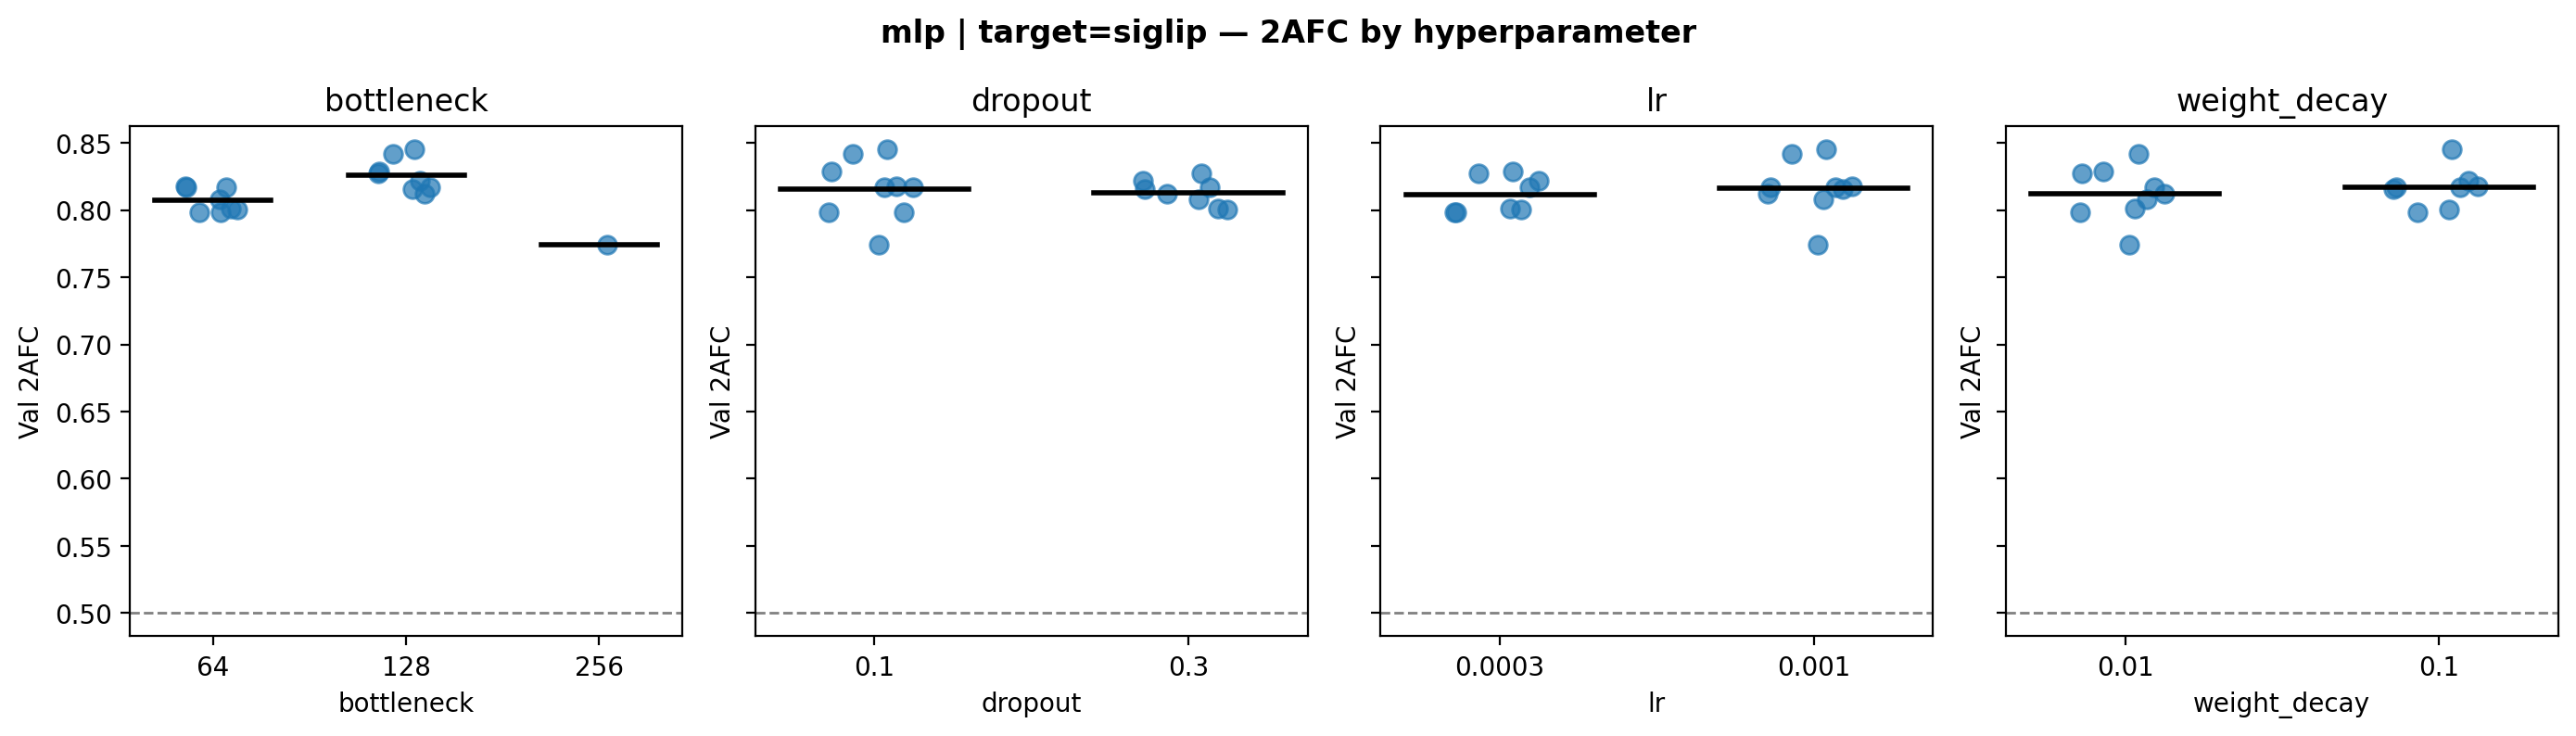

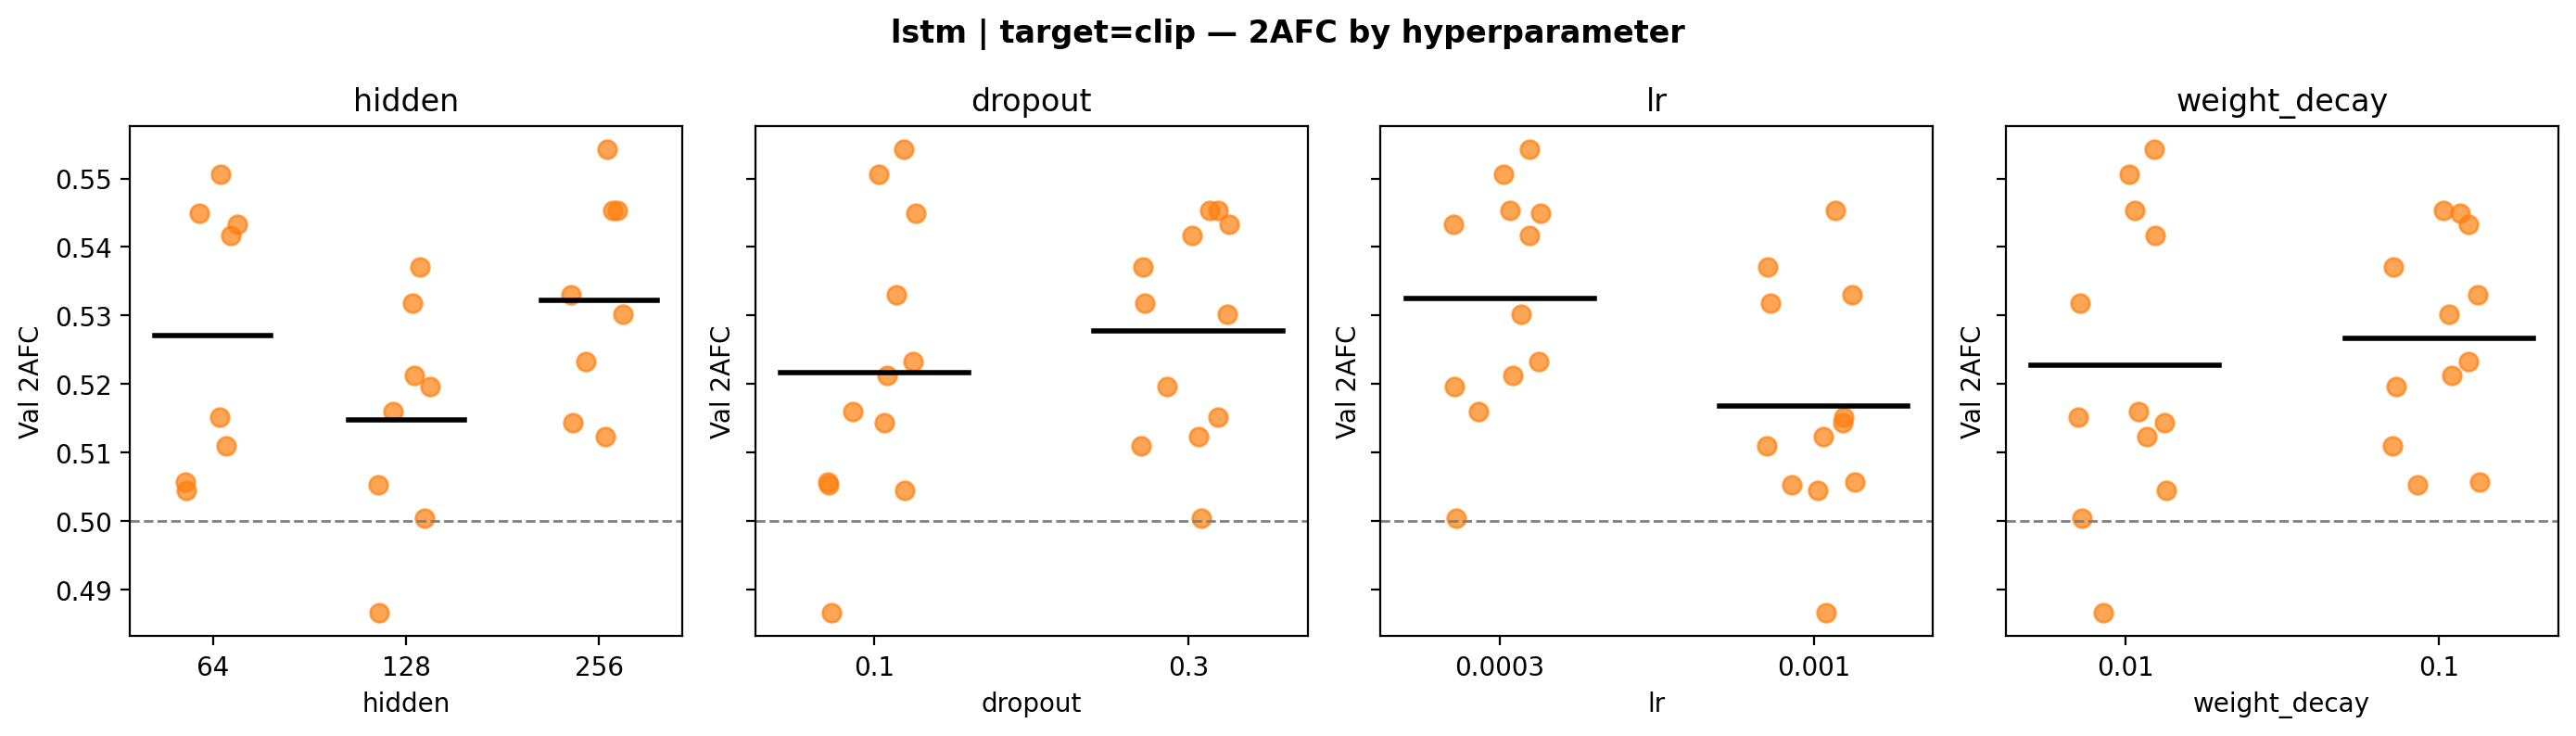

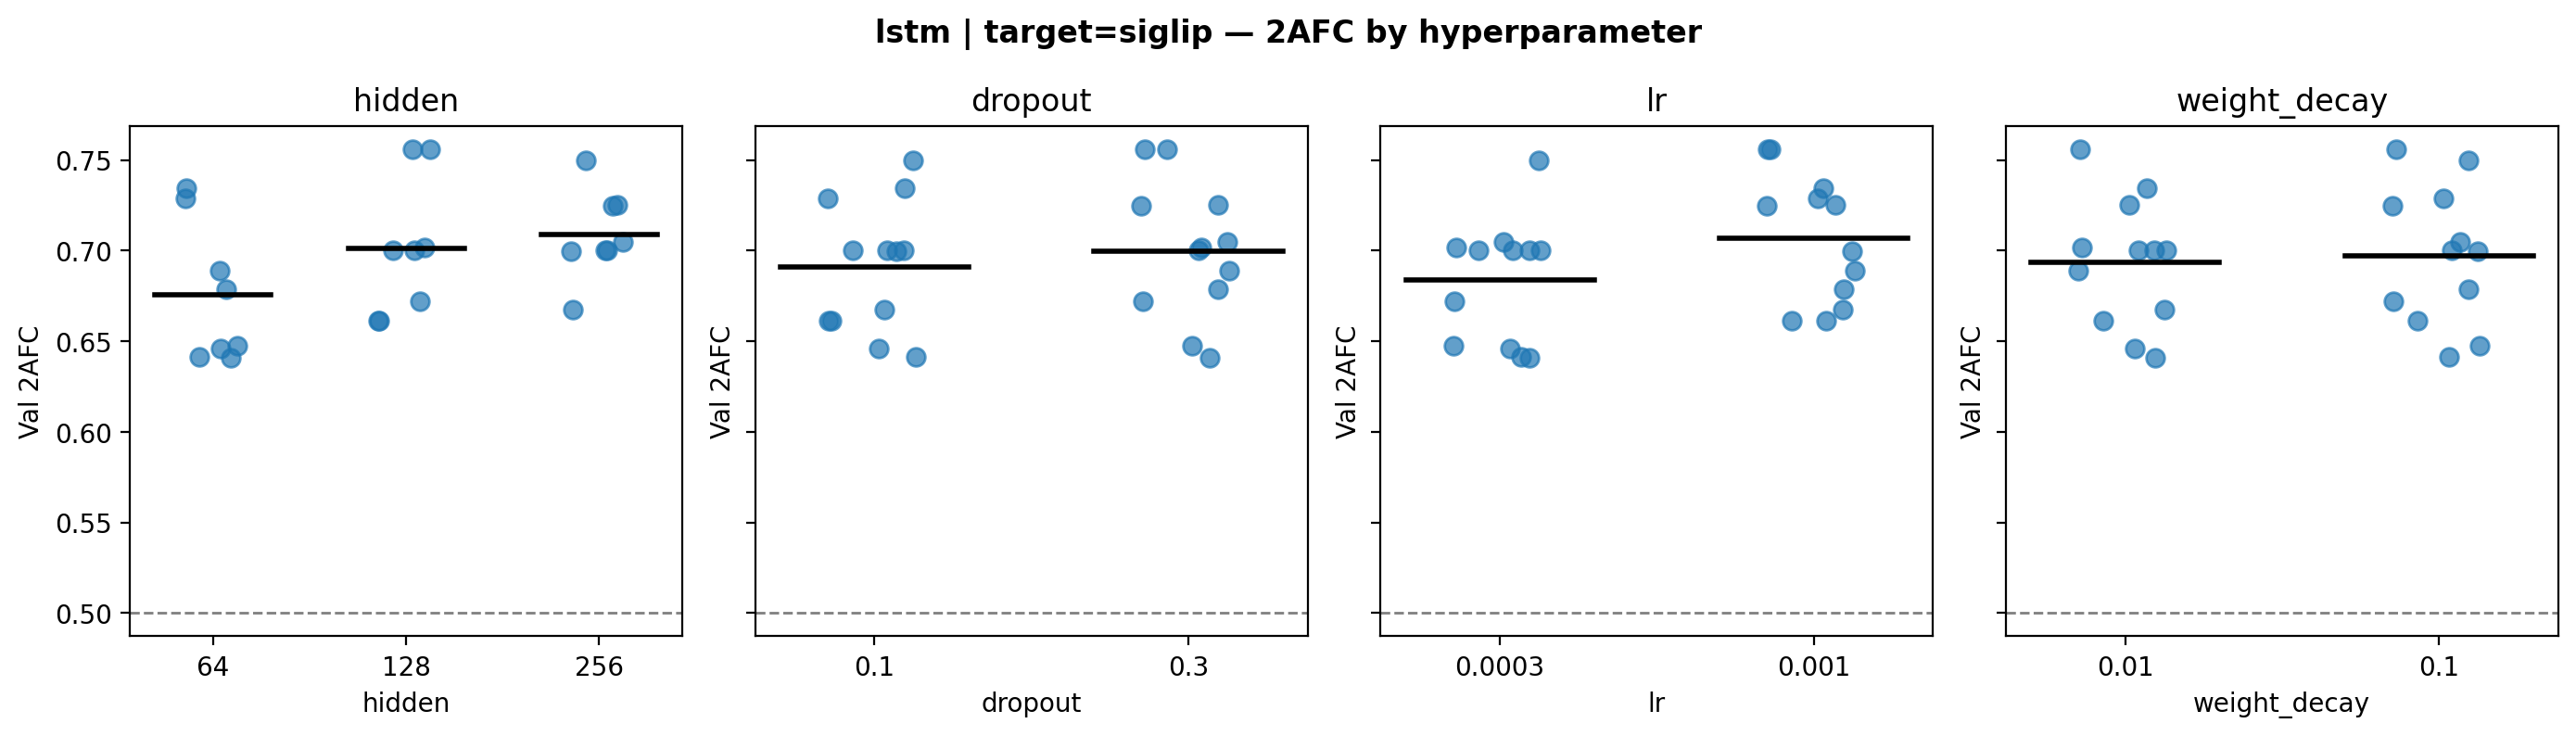

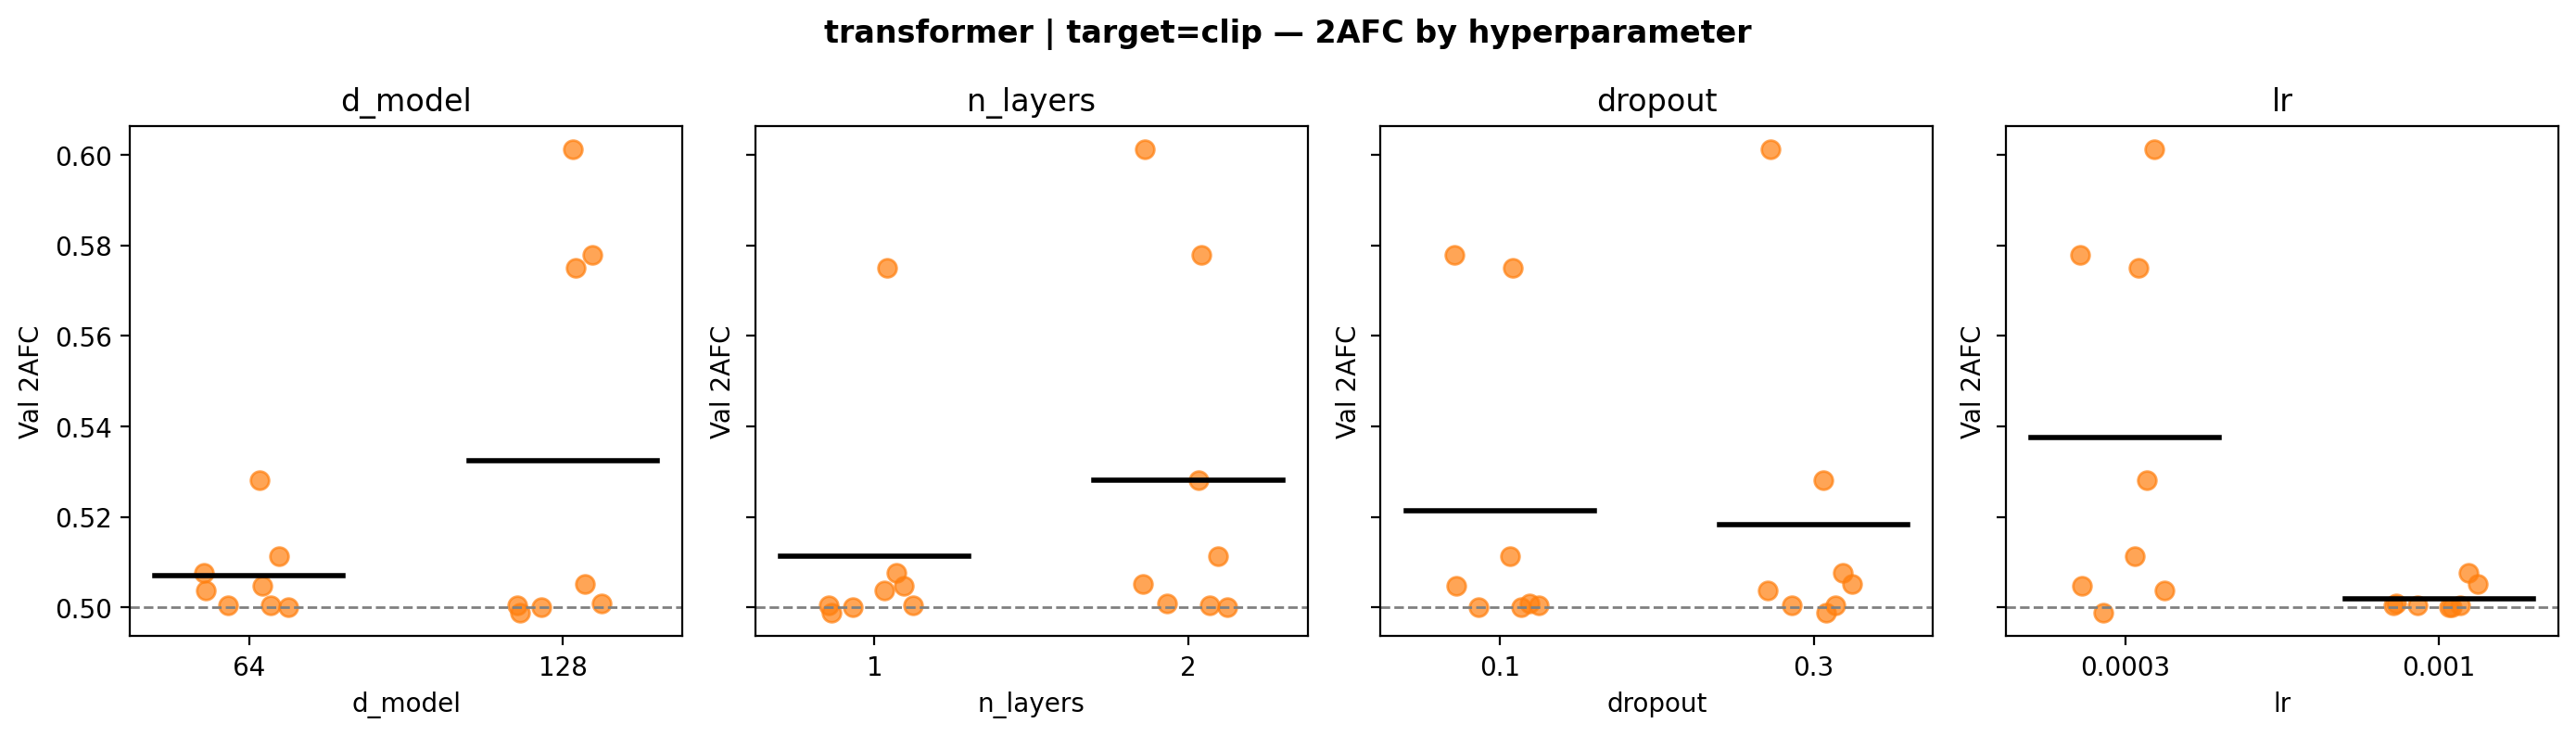

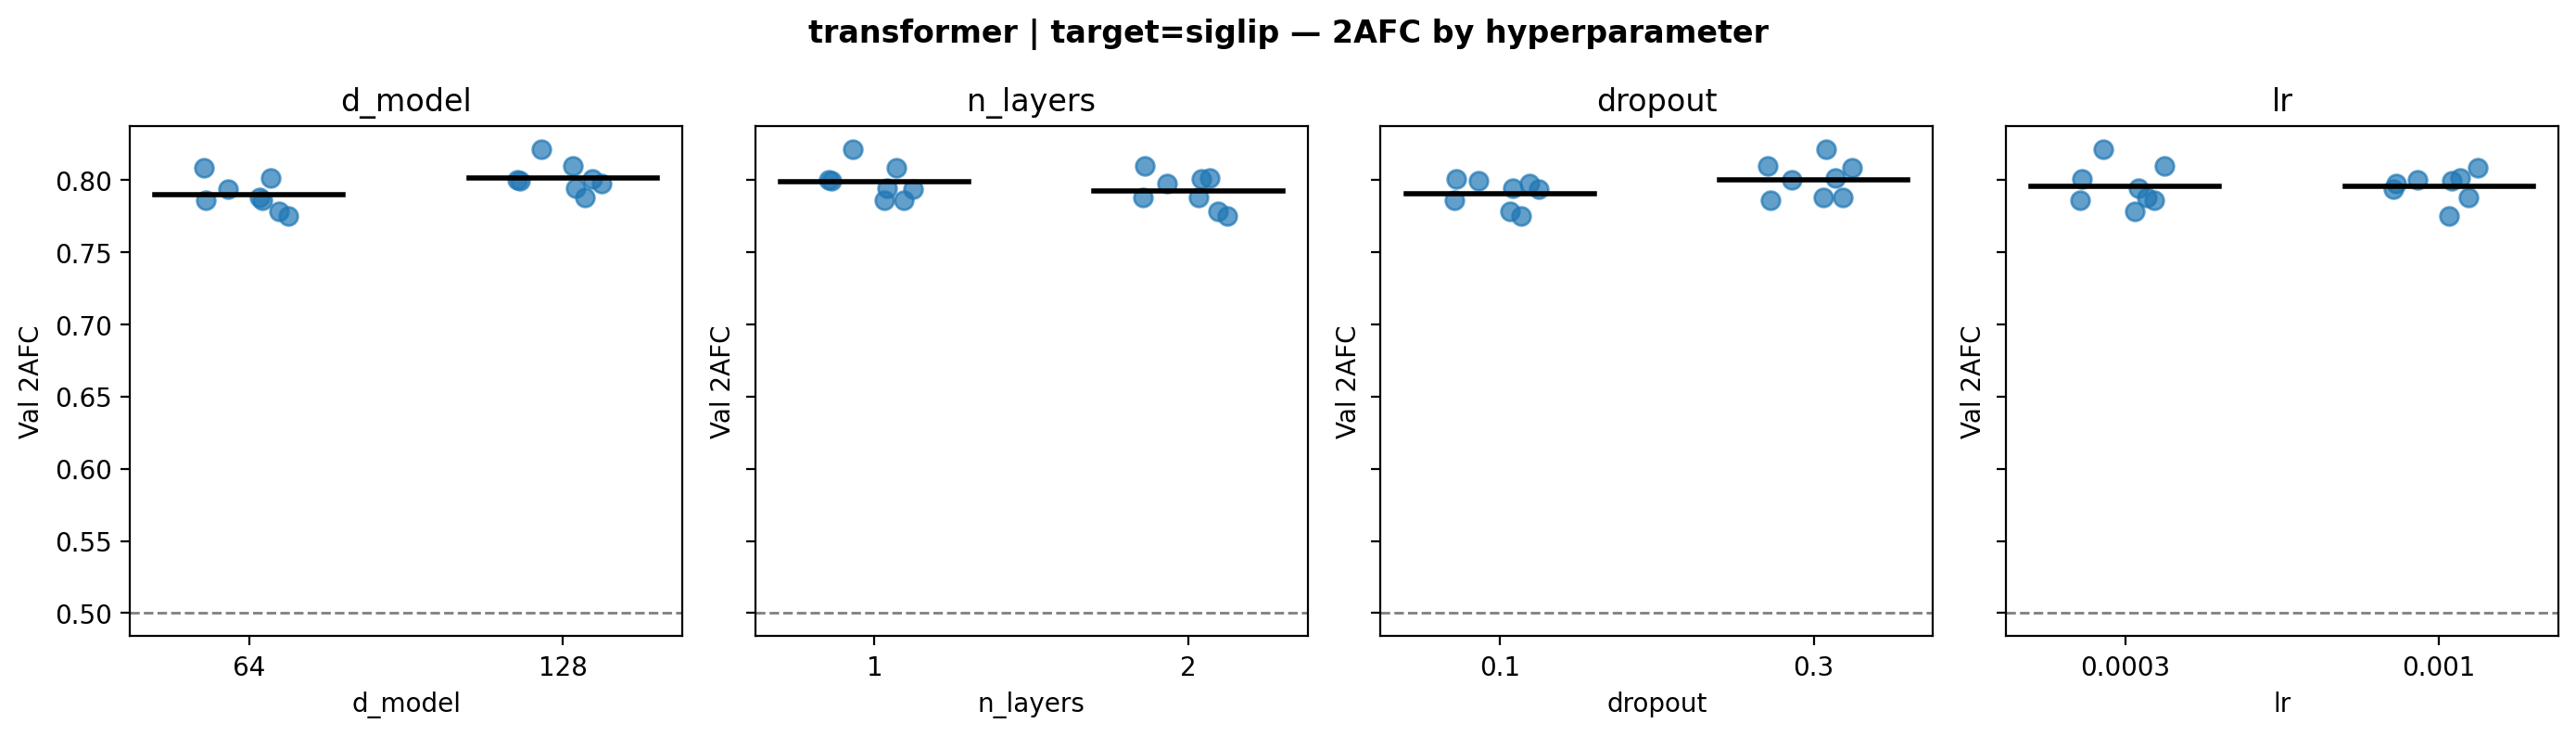

In [5]:
def strip_plot(ax, grp, x_col, title, color="tab:blue"):
    levels = sorted(grp[x_col].unique())
    for i, lvl in enumerate(levels):
        vals = grp.loc[grp[x_col] == lvl, "val_2afc"].values
        jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.7, s=50, color=color)
        ax.plot([i - 0.3, i + 0.3], [vals.mean(), vals.mean()], "k-", lw=2)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_xlabel(x_col)
    ax.set_ylabel("Val 2AFC")
    ax.set_title(title)
    ax.axhline(0.5, color="grey", lw=1, ls="--")

MODEL_HPARAMS = {
    "mlp":         ["bottleneck", "dropout", "lr", "weight_decay"],
    "lstm":        ["hidden",     "dropout", "lr", "weight_decay"],
    "transformer": ["d_model",    "n_layers", "dropout", "lr"],
}

for model_name, hparams in MODEL_HPARAMS.items():
    for tgt in TARGETS:
        sub = df[(df["model"] == model_name) & (df["target"] == tgt)]
        if sub.empty:
            continue
        fig, axes = plt.subplots(1, len(hparams), figsize=(3.5 * len(hparams), 4), sharey=True)
        fig.suptitle(f"{model_name} | target={tgt} — 2AFC by hyperparameter", fontweight="bold")
        for ax, col in zip(axes, hparams):
            if col in sub.columns:
                strip_plot(ax, sub, col, col, color=TARGET_PALETTE.get(tgt, "tab:blue"))
        plt.tight_layout()
        plt.show()

## Val 2AFC heatmap — LR × weight_decay (per target × model)

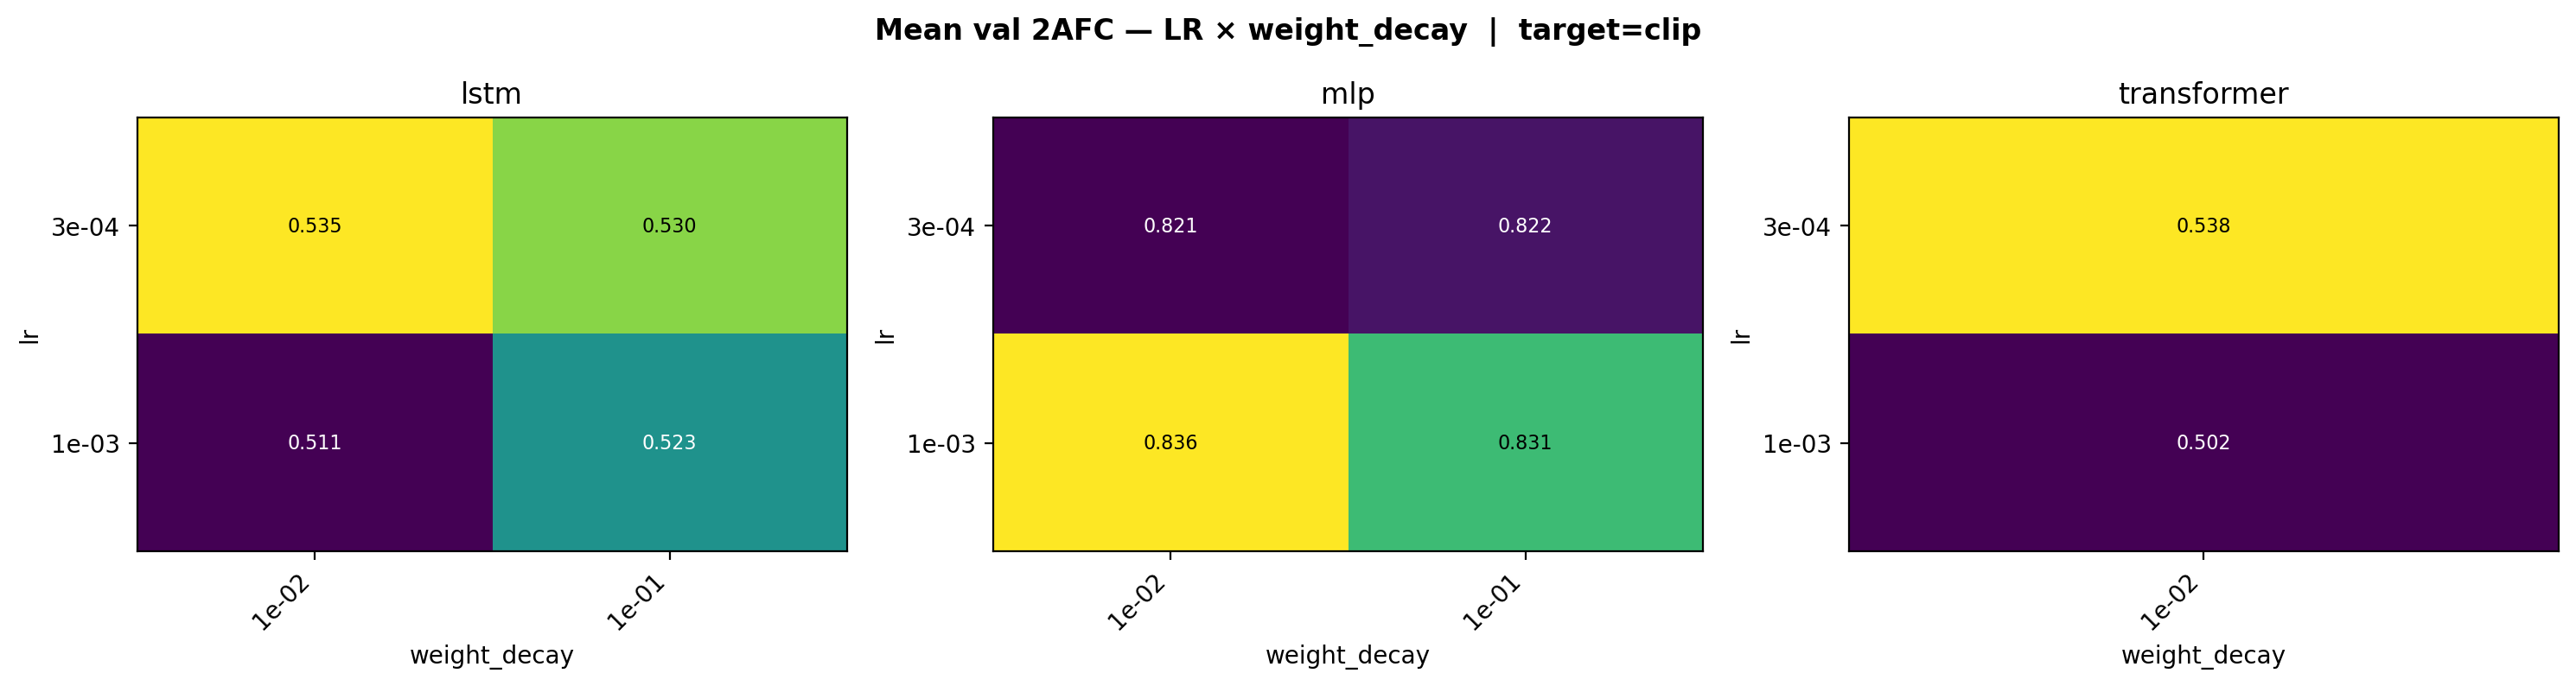

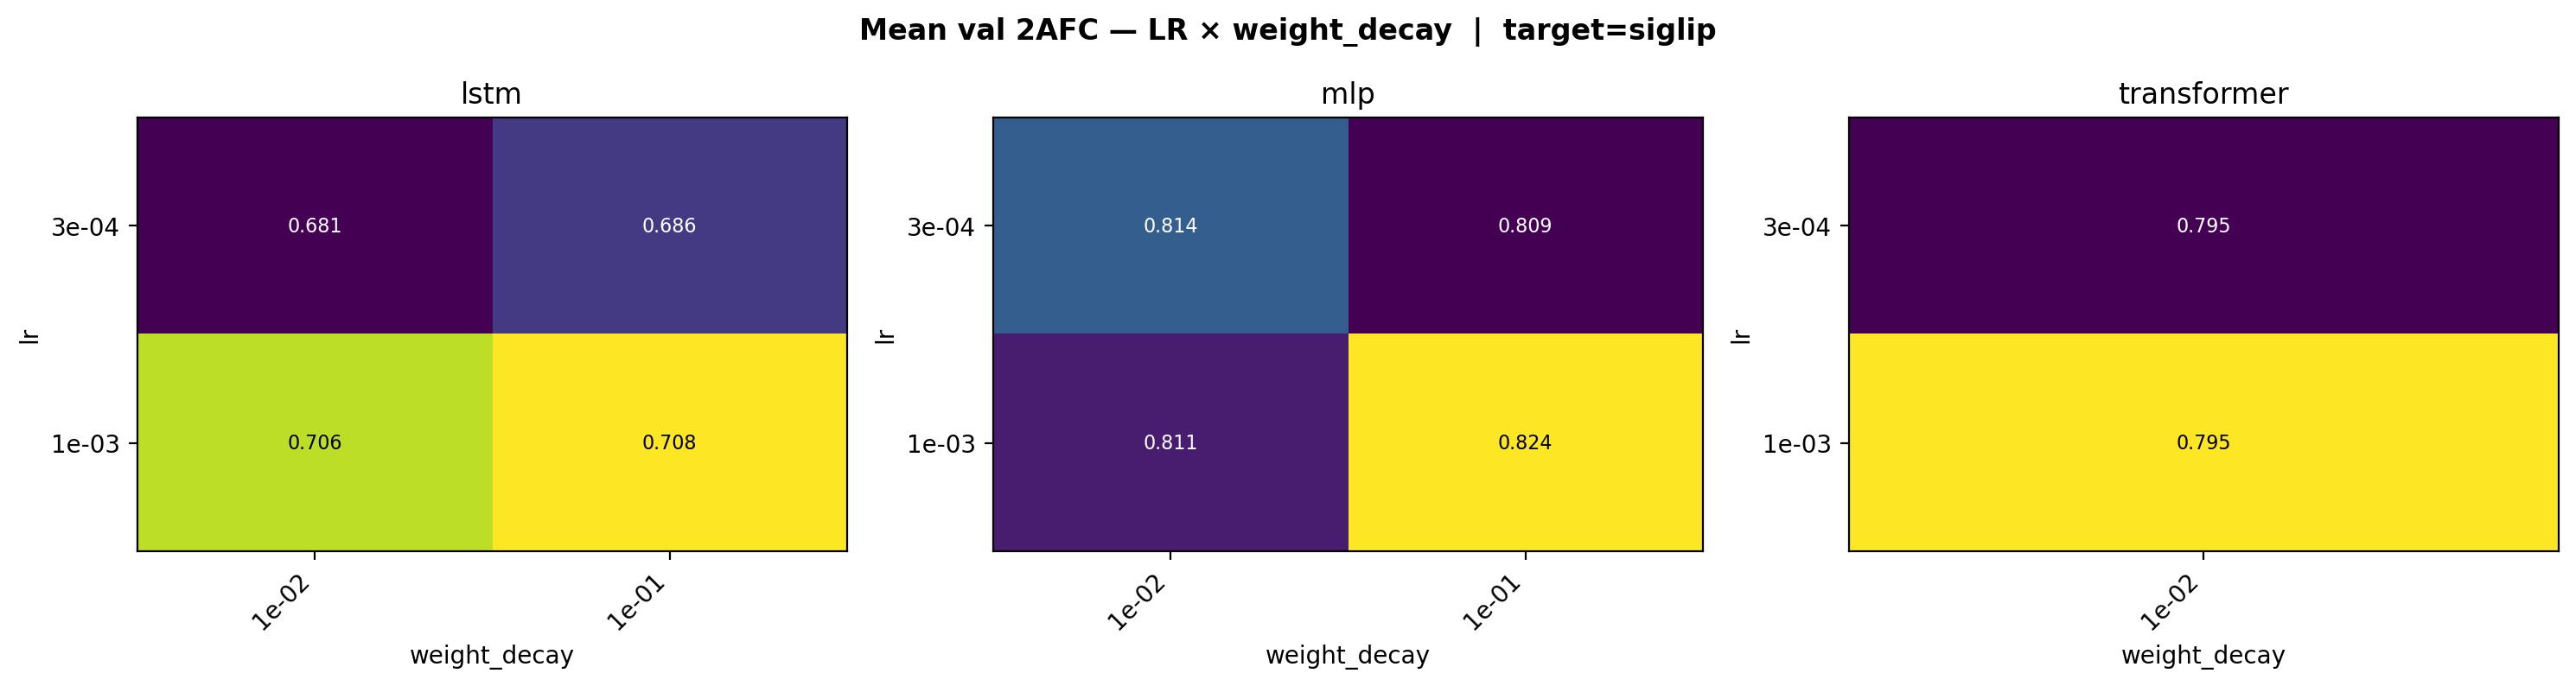

In [6]:
def heatmap(ax, grp, row_col, col_col, val_col, title, cmap="viridis", fmt=".3f"):
    pivot = grp.groupby([row_col, col_col])[val_col].mean().unstack()
    if pivot.empty:
        ax.set_visible(False)
        return
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.0e}" for v in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.0e}" for v in pivot.index])
    ax.set_xlabel(col_col)
    ax.set_ylabel(row_col)
    ax.set_title(title)
    mean_val = np.nanmean(pivot.values)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=8,
                        color="white" if v < mean_val else "black")

for tgt in TARGETS:
    sub = df[df["target"] == tgt]
    models_present = [m for m in MODELS if not sub[sub["model"] == m].empty]
    if not models_present:
        continue
    fig, axes = plt.subplots(1, len(models_present), figsize=(5 * len(models_present), 4))
    if len(models_present) == 1:
        axes = [axes]
    fig.suptitle(f"Mean val 2AFC — LR × weight_decay  |  target={tgt}", fontweight="bold")
    for ax, model_name in zip(axes, models_present):
        grp = sub[sub["model"] == model_name]
        if {"lr", "weight_decay", "val_2afc"}.issubset(grp.columns):
            heatmap(ax, grp, "lr", "weight_decay", "val_2afc", model_name)
    plt.tight_layout()
    plt.show()

## Top-10 runs overall

## SigLIP vs CLIP — best-run comparison per model

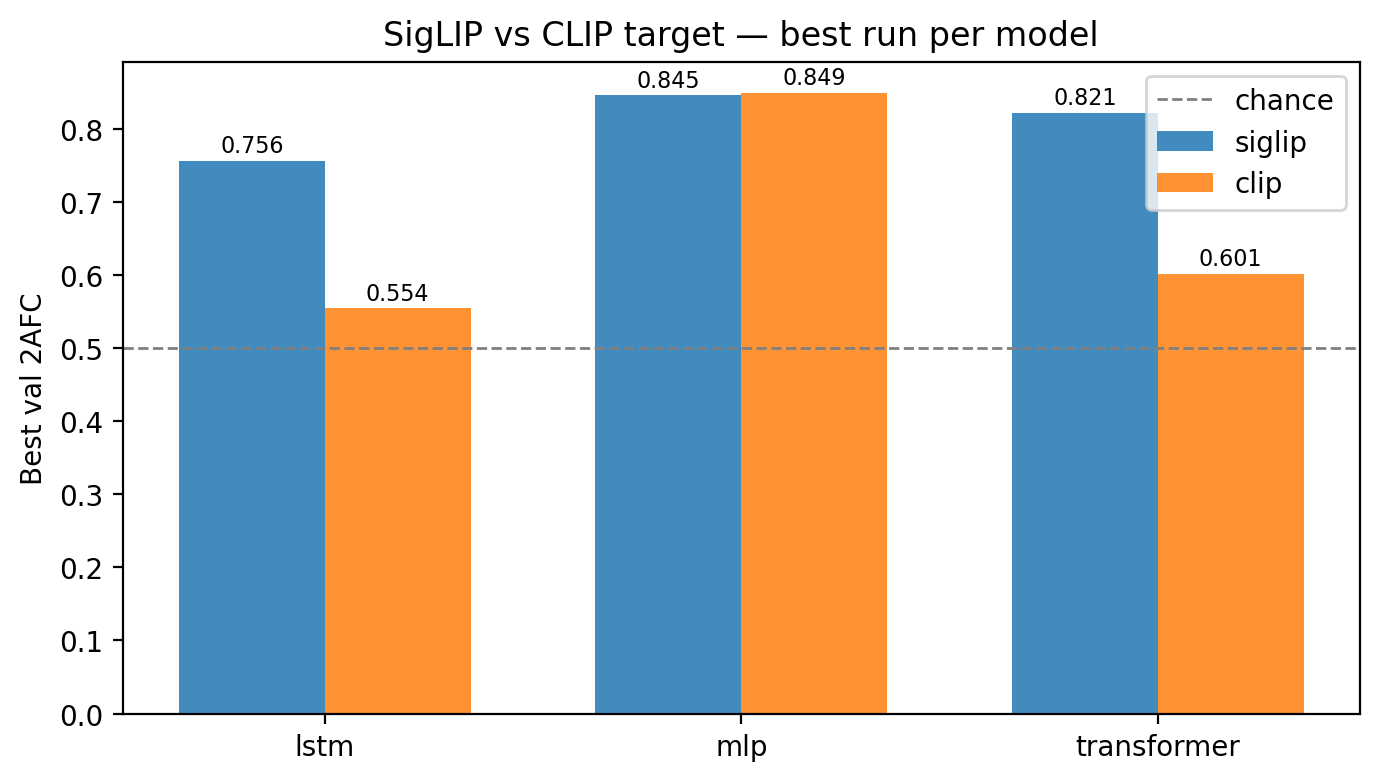

In [7]:
# Bar chart: best val 2AFC per (model, target)
best = (
    df.sort_values("val_2afc", ascending=False)
      .groupby(["model", "target"])
      .first()
      .reset_index()[["model", "target", "val_2afc"]]
)

models_list = sorted(best["model"].unique())
x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
for i, tgt in enumerate(["siglip", "clip"]):
    vals = [best.loc[(best["model"] == m) & (best["target"] == tgt), "val_2afc"].values
            for m in models_list]
    heights = [v[0] if len(v) > 0 else 0.0 for v in vals]
    bars = ax.bar(x + (i - 0.5) * width, heights, width,
                  label=tgt, color=TARGET_PALETTE.get(tgt, "grey"), alpha=0.85)
    for bar, h in zip(bars, heights):
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax.axhline(0.5, color="grey", lw=1, ls="--", label="chance")
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylabel("Best val 2AFC")
ax.set_title("SigLIP vs CLIP target — best run per model")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
top10_cols = [c for c in ["target", "model", "arch", "dropout", "lr", "weight_decay", "epoch", "val_loss", "val_2afc"] if c in df.columns]
df.sort_values("val_2afc", ascending=False)[top10_cols].head(10).reset_index(drop=True)

,target,model,arch,dropout,lr,weight_decay,epoch,val_loss,val_2afc
0,clip,mlp,bn128,0.3,0.0010,0.10,122,3.100570,0.848980
1,clip,mlp,bn256,0.3,0.0010,0.01,105,3.129429,0.848571
2,clip,mlp,bn256,0.1,0.0010,0.01,88,3.131137,0.846122
3,clip,mlp,bn128,0.3,0.0010,0.01,122,3.101815,0.845714
4,siglip,mlp,bn128,0.1,0.0010,0.10,107,3.126829,0.845306
5,clip,mlp,bn256,0.3,0.0003,0.10,126,3.141523,0.842449
6,siglip,mlp,bn128,0.1,0.0010,0.01,107,3.129164,0.842041
7,clip,mlp,bn256,0.1,0.0003,0.01,88,3.143774,0.840408
8,clip,mlp,bn256,0.1,0.0003,0.10,88,3.142949,0.840408
9,clip,mlp,bn256,0.3,0.0003,0.01,88,3.135622,0.838776
